In [36]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
path = str(Path.cwd().parent)
print(path)
sys.path.insert(1, path)

import numpy as np
import pandas as pd
import skforecast

print(skforecast.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/joaquin/Documents/GitHub/skforecast
0.18.0


In [37]:
# Libraries
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from skforecast.datasets import fetch_dataset
from aeon.forecasting.stats import ARIMA, ETS
from skforecast.sarimax import Sarimax
from skforecast.stats import Arar
from skforecast.experimental import ForecasterStats
from skforecast.experimental import backtesting_stats
from skforecast.model_selection import TimeSeriesFold, grid_search_sarimax
from skforecast.plot import set_dark_theme
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

In [38]:
# Download data
# ==============================================================================
data = fetch_dataset(name="h2o_exog", verbose=False)
data.index.name = 'datetime'

Train dates : 1992-04-01 00:00:00 --- 2005-06-01 00:00:00  (n=159)
Test dates  : 2005-07-01 00:00:00 --- 2008-06-01 00:00:00  (n=36)


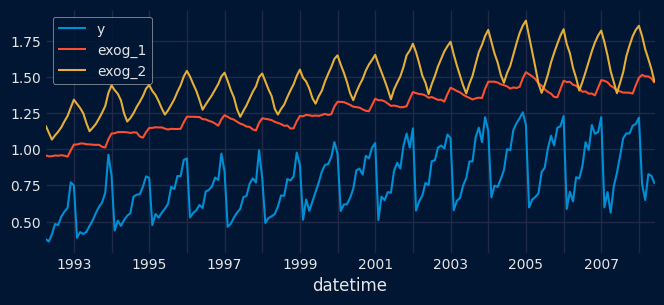

In [39]:
# Train-test dates
# ==============================================================================
end_train = '2005-06-01 23:59:59'
print(
    f"Train dates : {data.index.min()} --- {data.loc[:end_train].index.max()}  "
    f"(n={len(data.loc[:end_train])})"
)
print(
    f"Test dates  : {data.loc[end_train:].index.min()} --- {data.loc[:].index.max()}  "
    f"(n={len(data.loc[end_train:])})"
)
data_train = data.loc[:end_train]
data_test  = data.loc[end_train:]

# Plot
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(7, 3))
data.plot(ax=ax)
ax.legend();

In [40]:
# ARIMA model with skforecast.Sarimax
# ==============================================================================
sarimax = Sarimax(order=(1, 1, 1))
sarimax.fit(y=data_train['y'])
display(sarimax.summary())
predictions = sarimax.predict(steps=12)
predictions

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  159
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  89.934
Date:                Mon, 22 Sep 2025   AIC                           -173.869
Time:                        21:57:24   BIC                           -164.681
Sample:                    04-01-1992   HQIC                          -170.137
                         - 06-01-2005                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6316      0.143      4.420      0.000       0.352       0.912
ma.L1         -0.9535      0.054    -17.815      0.000      -1.058      -0.849
sigma2         0.0186      0.002      8.619      0.000       0.014       0.023
===================================================================================
Ljung-Box (L1) (Q):                   0.75   Jarque-Bera (JB):               167.05
Prob(Q):                              0.39   Prob(JB):                         0.00
Heteroskedasticity (H):               2.13   Skew:                            -1.66
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

,pred
2005-07-01,0.859454
2005-08-01,0.870312
2005-09-01,0.877170
2005-10-01,0.881502
2005-11-01,0.884238
2005-12-01,0.885966
2006-01-01,0.887057
2006-02-01,0.887747
2006-03-01,0.888182
2006-04-01,0.888457


In [41]:
# %%timeit
# arima = Sarimax(order=(1, 1, 1))
# arima.fit(y=data_train['y'])

In [42]:
arima = ARIMA(p=1, d=1, q=1, iterations=1000)
predictions = arima.iterative_forecast(y=data_train['y'], prediction_horizon=12)
predictions

array([0.86091451, 0.87270767, 0.88016437, 0.88487917, 0.88786029,
       0.88974523, 0.89093705, 0.89169063, 0.89216711, 0.89246839,
       0.89265888, 0.89277933])

In [43]:
# %%timeit
# arima = ARIMA(p=1, d=1, q=1, iterations=1000)
# arima.fit(y=data_train['y'])

In [44]:
ets = ETS(seasonal_period=1)
predictions = ets.iterative_forecast(y=data_train['y'], prediction_horizon=12)
predictions

array([0.82945776, 0.82945776, 0.82945776, 0.82945776, 0.82945776,
       0.82945776, 0.82945776, 0.82945776, 0.82945776, 0.82945776,
       0.82945776, 0.82945776])

In [45]:
# Create and fit Sarimax
# ==============================================================================
forecaster = ForecasterStats(
                 regressor=Sarimax(order=(12, 1, 1), seasonal_order=(0, 0, 0, 0), maxiter=200),
             )
forecaster.fit(y=data_train['y'], suppress_warnings=True)

predictions = forecaster.predict(steps=36)
predictions.head(3)

2005-07-01    0.957912
2005-08-01    0.960128
2005-09-01    1.108638
Freq: MS, Name: pred, dtype: float64

In [46]:
# %%timeit -r 10 -n 2
# forecaster = ForecasterStats(
#                  regressor=Sarimax(order=(12, 1, 1), seasonal_order=(0, 0, 0, 0), maxiter=200),
#              )

# forecaster.fit(y=data_train['y'], suppress_warnings=True)
# forecaster.predict(steps=36)

In [47]:
# Create and fit ARIMA aeon
# ==============================================================================
forecaster = ForecasterStats(
                 regressor=ARIMA(p=12, d=1, q=1, iterations=1000),
             )

forecaster.fit(y=data_train['y'], suppress_warnings=True)
predictions = forecaster.predict(steps=36)
predictions.head(3)

2005-07-01    0.968462
2005-08-01    0.950627
2005-09-01    1.129492
Freq: MS, Name: pred, dtype: float64

In [48]:
# %%timeit -r 10 -n 2
# forecaster = ForecasterStats(
#                  regressor=ARIMA(p=12, d=1, q=1, iterations=1000),
#              )

# forecaster.fit(y=data_train['y'], suppress_warnings=True)
# forecaster.predict(steps=36)

In [49]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
        steps              = 12,
        initial_train_size = len(data_train),
        refit              = True,
        fixed_train_size   = False,
)
forecaster = ForecasterStats(
                 regressor=Sarimax(order=(12, 1, 1), seasonal_order=(0, 0, 0, 0), maxiter=200),
             )
metric_sarimax, pred_sarimax = backtesting_stats(
                    forecaster = forecaster,
                    y          = data['y'],
                    cv         = cv,
                    metric     = 'mean_absolute_error'
                )


  0%|          | 0/3 [00:00<?, ?it/s]

In [50]:
forecaster = ForecasterStats(
                 regressor=ARIMA(p=12, d=1, q=1, iterations=1000),
             )
metric_arima, pred_arima = backtesting_stats(
                    forecaster = forecaster,
                    y          = data['y'],
                    cv         = cv,
                    metric     = 'mean_absolute_error'
                )

  0%|          | 0/3 [00:00<?, ?it/s]

In [52]:
forecaster = ForecasterStats(
                 regressor=Arar(),
             )
metric_arar, pred_arar = backtesting_stats(
                    forecaster = forecaster,
                    y          = data['y'],
                    cv         = cv,
                    metric     = 'mean_absolute_error'
                )

  0%|          | 0/3 [00:00<?, ?it/s]

In [53]:
forecaster = ForecasterStats(
                 regressor=ETS(seasonal_period=12),
             )
metric_ets, pred_ets = backtesting_stats(
                    forecaster = forecaster,
                    y          = data['y'],
                    cv         = cv,
                    metric     = 'mean_absolute_error'
                )

  0%|          | 0/3 [00:00<?, ?it/s]

In [59]:
print(f"MAE sarimax: {metric_sarimax.at[0, 'mean_absolute_error']}")
print(f"MAE arima  : {metric_arima.at[0, 'mean_absolute_error']}")
print(f"MAE arar   : {metric_arar.at[0, 'mean_absolute_error']}")
print(f"MAE ets    : {metric_ets.at[0, 'mean_absolute_error']}")

MAE sarimax: 0.06673277427316084
MAE arima  : 0.08120953479546446
MAE arar   : 0.07614306524678896
MAE ets    : 0.2026519577955612


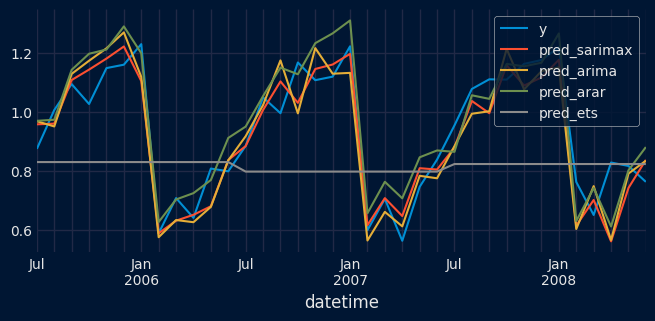

In [55]:
fig, ax = plt.subplots(figsize=(7, 3))
data['y'].loc[data_test.index].plot(ax=ax, label='y')
pred_sarimax['pred'].plot(ax=ax, label='pred_sarimax')
pred_arima['pred'].plot(ax=ax, label='pred_arima')
pred_arar['pred'].plot(ax=ax, label='pred_arar')
pred_ets['pred'].plot(ax=ax, label='pred_ets')
ax.legend();